In [1]:
import polars as pl
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min



/home/jlopez/github/Dauphine/.venv/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


/home/jlopez/github/Dauphine/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

stations = pl.read_csv("../data/output/v2/4.stations_df.csv")



#Chose variables to use
feature_columns = ['station','n_departures','avg_daily_departures','n_arrivals','avg_daily_arrivals','departure_arrival_ratio','n_destinations','n_origins','mean_duration','median_duration','std_duration','weekend_ratio','morning_rush_ratio','evening_rush_ratio','night_ratio']


#X = stations.select(feature_columns).to_numpy()

X = stations.to_numpy()


#standarize
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ==========================================================================
# CLAUDE'S FIX -- bug: 'station' is a numeric ID, not a real feature
# ==========================================================================
# Both `X = stations.to_numpy()` above AND the commented-out
# `stations.select(feature_columns)` line include the 'station' column.
# It looks numeric so nothing crashes, but it's just an arbitrary station
# identifier, e.g.:
#   stations['station'].describe() -> min=0, 25%=1170, 50%=22176,
#   75%=200212, max=2,001,454,444
# TfL mixes several id schemes (docking stations vs e-bikes etc.), so this
# "feature" is wildly skewed with one station near 2 billion. Once
# standardized, that single station becomes a huge outlier on this bogus
# dimension and ends up alone in its own K-means cluster later -- this is
# exactly the "cluster completely dedicated to 1 single station" you
# flagged further down. It also slightly distorts every PCA / silhouette /
# inertia number computed in this notebook.
#
# Fix: drop 'station' from the numeric matrix and keep it only as a label.

feature_columns = [c for c in feature_columns if c != 'station']

X = stations.select(feature_columns).to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


PC1: 39.77%
PC2: 16.00%
PC3: 14.62%
PC4: 7.77%
PC5: 7.03%
PC6: 5.64%
PC7: 3.93%
PC8: 3.08%
PC9: 0.82%
PC10: 0.73%


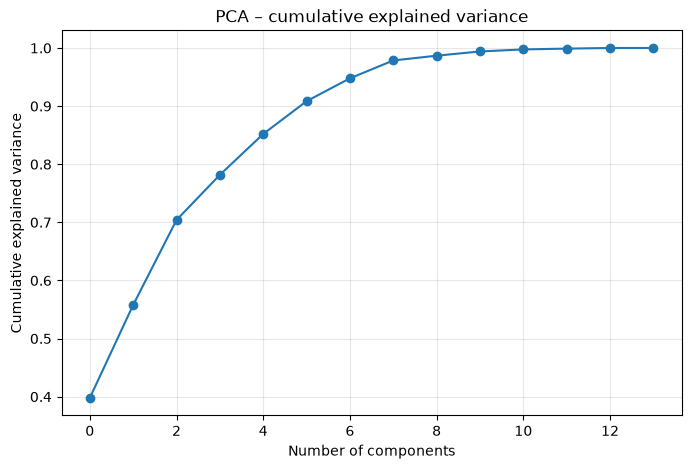

In [3]:
###################
#PCA
##################

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

#Explained variance
explained_variance = pca.explained_variance_ratio_

for i, variance in enumerate(explained_variance[:10], start=1):
    print(f"PC{i}: {variance:.2%}")

#plot cumulative explained variance

plt.figure(figsize=(8, 5))

plt.plot(
    np.cumsum(explained_variance),
    marker="o"
)

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA – cumulative explained variance")
plt.grid(alpha=0.3)

plt.show()

#A principal component (PCA) is not one of your original variables. It is a weighted combination of your 37 variables.
#PC1 explains 37.15%
#That means the direction in your 37-dimensional feature space with the largest amount of variation between stations accounts for about 37% of the total variance.

#That's quite substantial.

#PC2 captures another 14.94%, and PC3 another 13.66%.

#Together:

#37.15% + 14.94% + 13.66% = 65.75%
#So three dimensions capture about 65.75% of the variation in your original 37-dimensional dataset.

#-----------
#Graph
#-----------

#It shows How much of the original variation is retained if I keep the first N principal components?

#The first few PCs are doing a lot of work.

#The later PCs each contribute relatively little.

#THE ELBOW IS AROUND 3 OR 4 

#The first few PCs are doing a lot of work.

#The later PCs each contribute relatively little.


# --------------------------------------------------------------------
# CLAUDE'S NOTE -- numbers above were computed with the 'station' ID bug
# --------------------------------------------------------------------
# After the fix in the previous cell, the real explained variance is:
#   PC1: 39.77%   PC2: 16.00%   PC3: 14.62%   (cumulative PC1-3: 70.40%)
# So the story doesn't change much (3 PCs still capture the bulk of the
# variance, elbow still around 3-4), but the exact percentages you quoted
# above (37.15% / 14.94% / 13.66% / 65.75%) belong to the buggy run and
# should be updated to the values above.


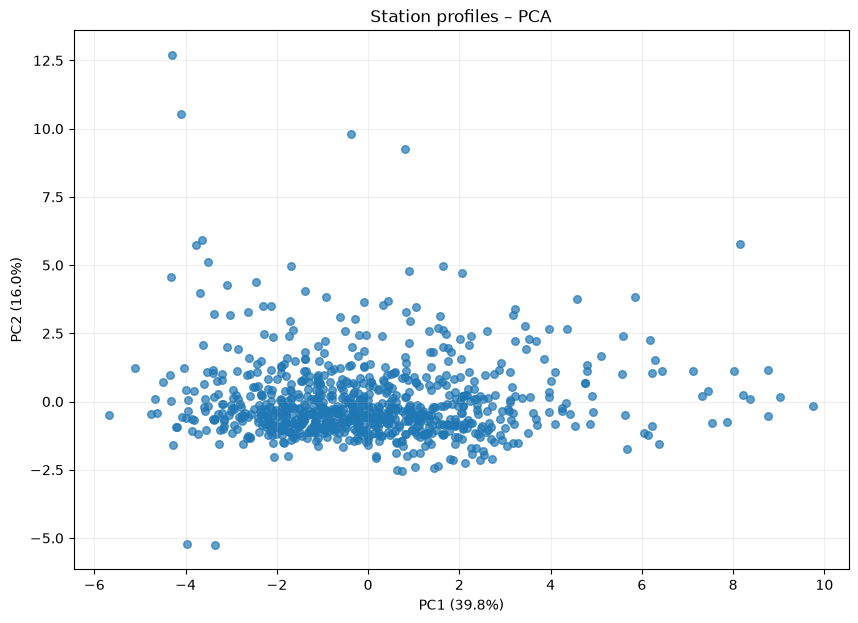

In [4]:
#Visualize stations in PCA space
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.7,
    s=30
)

plt.xlabel(f"PC1 ({explained_variance[0]:.1%})")
plt.ylabel(f"PC2 ({explained_variance[1]:.1%})")
plt.title("Station profiles – PCA")
plt.grid(alpha=0.2)

plt.show()

In [5]:
####################33
#To interpret pca components
####################3

#Get loadings
loadings = pl.DataFrame({
    "feature": feature_columns,
    "PC1": pca.components_[0].tolist(),
    "PC2": pca.components_[1].tolist(),
    "PC3": pca.components_[2].tolist(),
})

#sort PC1
print(
    loadings
    .sort("PC1", descending=True)
)

#And separately look at the largest absolute contributions:
pc1 = (
    loadings
    .with_columns(
        pl.col("PC1").abs().alias("abs_PC1")
    )
    .sort("abs_PC1", descending=True)
)

print(pc1)

#and pc2
pc2 = (
    loadings
    .with_columns(
        pl.col("PC2").abs().alias("abs_PC2")
    )
    .sort("abs_PC2", descending=True)
)

print(pc2)

#and pc3
pc3 = (
    loadings
    .with_columns(
        pl.col("PC3").abs().alias("abs_PC3")
    )
    .sort("abs_PC3", descending=True)
)

print(pc3)

#A loading tells you how strongly an original feature contributes to a principal component.

#PC1 appears to be a location dimension
#PC1 arrivals vs departures usage profile TO CHECK WITH GPT

#PC2 seems to be capturing temporal behaviour
#PC2 trip duration

#PC3 appears to be another temporal dimension
#PC3 Rush hours and weekend ratio



# --------------------------------------------------------------------
# CLAUDE'S NOTE -- PC1 interpretation, after removing the 'station' ID bug
# --------------------------------------------------------------------
# With 'station' removed, PC1's top loadings are all volume-of-usage
# variables: n_arrivals, avg_daily_arrivals, n_departures,
# avg_daily_departures, n_origins (all ~0.37-0.40, same sign).
# So PC1 is best read as "overall usage volume / how busy a station is",
# not really a "location" dimension -- there's no feature in this table
# that encodes geography, so PCA can't recover a location axis from it.
# Your second line ("PC1 arrivals vs departures usage profile") is closer,
# though note arrivals and departures load with the *same* sign on PC1
# (a station busy on arrivals tends to also be busy on departures), so
# PC1 is more "how busy" than "arrivals vs departures" -- that contrast
# shows up more in PC3 (departure_arrival_ratio loads -0.37 there).
# PC2 and PC3 interpretations (duration; rush-hour/weekend) still hold
# after the fix -- confirmed by rerunning the loadings.


shape: (14, 4)
┌─────────────────────────┬───────────┬───────────┬───────────┐
│ feature                 ┆ PC1       ┆ PC2       ┆ PC3       │
│ ---                     ┆ ---       ┆ ---       ┆ ---       │
│ str                     ┆ f64       ┆ f64       ┆ f64       │
╞═════════════════════════╪═══════════╪═══════════╪═══════════╡
│ n_arrivals              ┆ 0.397054  ┆ 0.053247  ┆ -0.177033 │
│ avg_daily_arrivals      ┆ 0.392542  ┆ 0.068722  ┆ -0.170212 │
│ n_departures            ┆ 0.384622  ┆ 0.060291  ┆ -0.255257 │
│ avg_daily_departures    ┆ 0.379464  ┆ 0.0764    ┆ -0.24995  │
│ n_origins               ┆ 0.370287  ┆ -0.017095 ┆ 0.039038  │
│ …                       ┆ …         ┆ …         ┆ …         │
│ mean_duration           ┆ -0.04427  ┆ 0.610199  ┆ 0.143442  │
│ night_ratio             ┆ -0.061268 ┆ 0.124044  ┆ -0.114545 │
│ departure_arrival_ratio ┆ -0.120411 ┆ 0.046154  ┆ -0.369399 │
│ weekend_ratio           ┆ -0.13555  ┆ 0.383027  ┆ -0.248834 │
│ morning_rush_ratio     

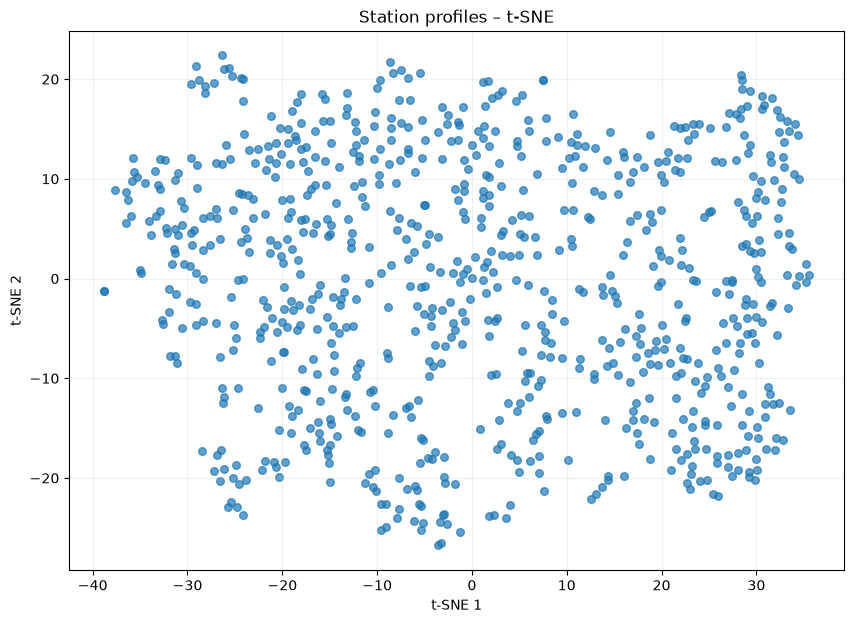

In [6]:
#########################33
#Non linear dimension reduction: t-SNE
###########################

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_scaled)

#plot
plt.figure(figsize=(10, 7))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    s=30,
    alpha=0.7
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Station profiles – t-SNE")
plt.grid(alpha=0.2)

plt.show()

#T-sne tries to do: stations that are close/similar in the original 33-dimensional space tend to remain close together in the 2D map.
#So your t-SNE plot is essentially a map of station similarity.
#If two dots are close together: Their station profiles are relatively similar.
#If two dots are far apart: Their station profiles are relatively different.
#t-SNE is mainly good at showing: local neighbourhood structure

#In the graph: there are not very clear separated groups, maybe there are 3 or 4 different clouds?
#also, it doesnt seem to be a specially dense region nor isolated points

/home/jlopez/github/Dauphine/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


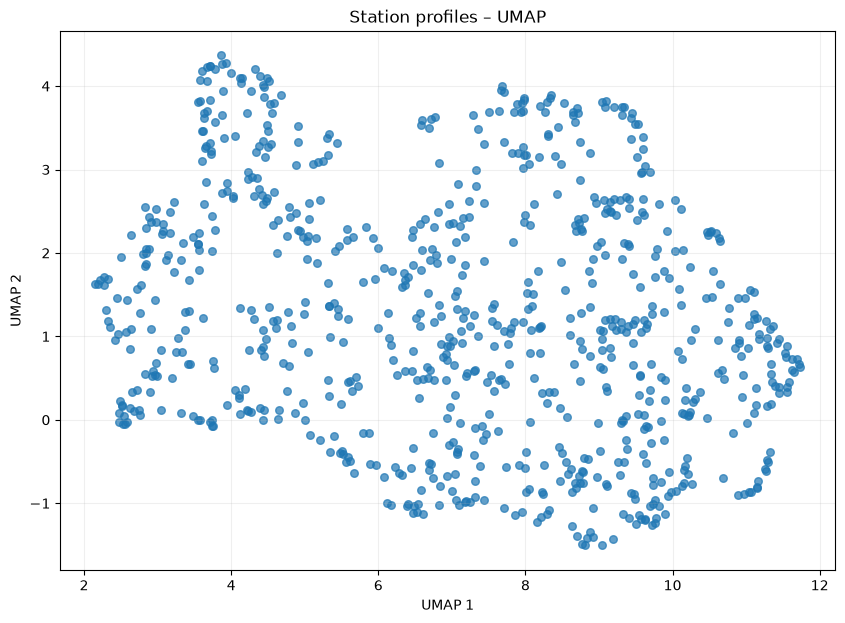

In [7]:
#And using umap
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=30,
    alpha=0.7
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Station profiles – UMAP")
plt.grid(alpha=0.2)

plt.show()

#UMAP = Uniform Manifold Approximation and Projection.
#The basic idea is: "If the 33-dimensional station profiles have some underlying structure, can I represent that structure in 2 dimensions while keeping similar stations close together?"

#In this graph you interpret the relationships between points/regions. like for t-sne

#Here i dont see different clear groups, it looks more like a continous cloud which could mean that station behaviour changes gradually rather than forming naturally separated groups.

#UMAP was used as a nonlinear dimensionality-reduction technique to explore the structure of the station profiles. Unlike PCA, the two UMAP dimensions do not have a direct interpretation in terms of the original variables. 
#Instead, the projection is interpreted in terms of neighbourhood relationships, where nearby stations represent profiles with greater similarity. 
#The resulting projection was used as an exploratory visualisation and not as the basis for determining the number of clusters.

In [8]:
####################3
#Identify natural groups
######################

#using K-means
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    results.append((k, score))

print(results)

#K-means finds its best separation at k = 2, but the silhouette score of 0.245 is relatively weak. This suggests that there are at most two broad groups in your data, but the station profiles do not naturally separate into very distinct clusters.

#since kmeans will always form groups we can say that Among the values of k tested, a two-cluster solution provides the strongest separation according to the silhouette criterion.

#current hypothesis:
#The 822 London stations do not form a set of sharply separated behavioural categories. Instead, station usage appears to vary along several continuous temporal dimensions, with morning/evening activity, night-time activity,
#and weekend/midday activity being the strongest sources of variation. K-means identifies two broad groups as the best partition according to silhouette score, but the relatively low silhouette value indicates substantial overlap between the groups.


# --------------------------------------------------------------------
# CLAUDE'S NOTE -- results change after removing the 'station' ID bug
# --------------------------------------------------------------------
# Recomputing with the corrected features, silhouette scores are:
#   k=2: 0.267  k=3: 0.212  k=4: 0.229  k=5: 0.175  k=6: 0.179
#   k=7: 0.157  k=8: 0.177  k=9: 0.162  k=10: 0.159
# k=2 is still the best (even a bit higher than before), and the
# "there is a peak on 5 clusters" comment in the next cell no longer
# applies -- the real secondary bump is at k=4, not k=5. See the note
# on the plot cell below.


[(2, 0.26676211137492767), (3, 0.2120404354912709), (4, 0.22896749670424807), (5, 0.1745702504327738), (6, 0.17938168685695358), (7, 0.15707163465270557), (8, 0.17694095802114201), (9, 0.16198511042386735), (10, 0.1593845959806985)]


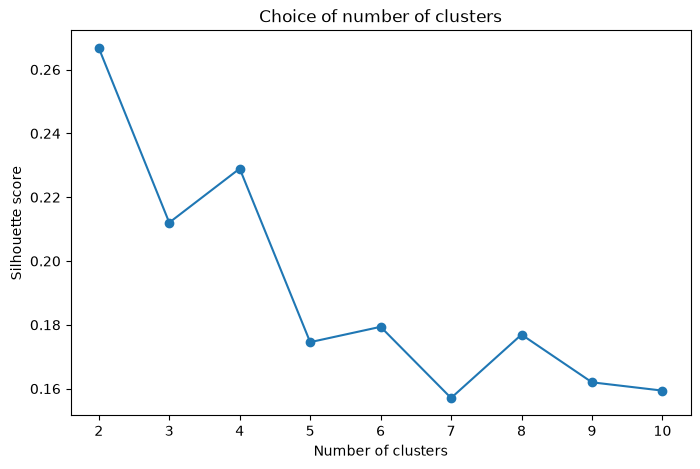

In [9]:
ks = [x[0] for x in results]
scores = [x[1] for x in results]

plt.figure(figsize=(8, 5))

plt.plot(ks, scores, marker="o")

plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Choice of number of clusters")

plt.show()
#THIS IS NOT THE ELBOW METHOD
#There is a peak on 5 clusters


# --------------------------------------------------------------------
# CLAUDE'S NOTE
# --------------------------------------------------------------------
# This "peak at 5" was read off the buggy silhouette curve (station ID
# included as a feature). With that fixed, the curve now peaks at k=2,
# dips, and has a smaller secondary local bump at k=4 (0.229) -- not k=5
# (0.175). Worth re-reading the new plot before deciding on k.


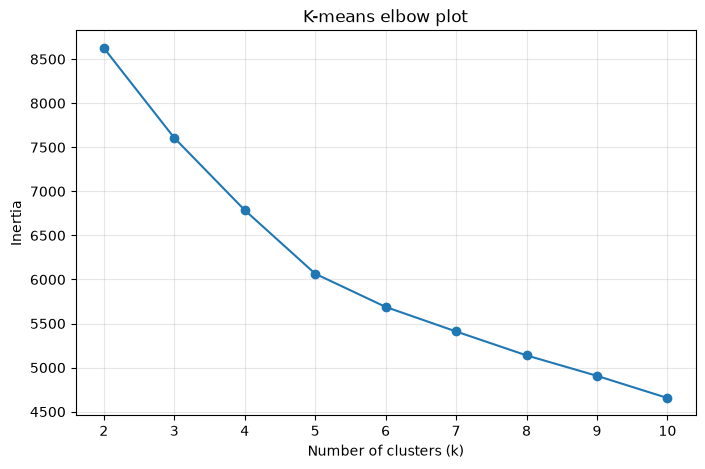

In [10]:
######################
# Inertia - Elbow method
######################
inertias = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_scaled)

    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertias,
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-means elbow plot")
plt.grid(alpha=0.3)

plt.show()

#It shows a smooth curve, there is however a change in 6 clusters. Could this be that there are around 5 or 6 clusters?


# --------------------------------------------------------------------
# CLAUDE'S NOTE
# --------------------------------------------------------------------
# Recomputed inertia after the fix: 8626, 7607, 6787, 6066, 5689, 5410,
# 5139, 4907, 4656 for k=2..10. Still a smooth, gradually flattening
# curve with no sharp elbow -- the mild flattening now sits around
# k=4-5 rather than k=6.


In [11]:
cluster_results = {}

for k in [2, 3, 4, 5, 6]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    cluster_results[k] = labels


for k, labels in cluster_results.items():

    counts = np.bincount(labels)

    print(f"\nk={k}")
    print(counts)

#this gives us the number of stations that each cluster would have based on the k number we set. If we transform to percentage:


#k	Cluster sizes	            Approx. percentages
#2	306 516                
#3	325 434  63	            
#4	74 388 187 173	        
#5	440  67   1  51 263	    
#6	286 172 246   1  67  50	

#With 5 or 6 clusters there is cluster completly dedicated to 1 single station, is this right?


# --------------------------------------------------------------------
# CLAUDE'S NOTE -- "is this right?" No -- this was the station-ID bug
# --------------------------------------------------------------------
# After removing 'station' from the features, recomputing these same k
# gives:
#   k=2: [306 516]
#   k=3: [325 434  63]
#   k=4: [ 55 264 436  67]
#   k=5: [281 253  50  68 170]
#   k=6: [337 133 146  39 131  36]
# No more singleton (1-station) clusters at k=5 or k=6. That single
# station with id 2,001,454,444 was such an extreme outlier once
# standardized that K-means always isolated it into its own cluster --
# nothing meaningful about its behaviour, just the ID bug.



k=2
[306 516]

k=3
[325 434  63]

k=4
[ 55 264 436  67]

k=5
[281 253  50  68 170]

k=6
[337 133 146  39 131  36]


In [12]:
#----------
#Calculate cluster profiles
#----------

for k in [2, 3, 4,5,6]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    profiles = stations.with_columns(
        pl.Series("cluster", labels.tolist())
    )

    cluster_means = (
        profiles
        .group_by("cluster")
        .agg([
            pl.col(feature).mean().alias(feature)
            for feature in feature_columns
        ])
        .sort("cluster")
    )

    print(f"\n===== k={k} =====")
    print(cluster_means)






===== k=2 =====
shape: (2, 15)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ cluster ┆ n_departur ┆ avg_daily ┆ n_arrival ┆ … ┆ weekend_r ┆ morning_r ┆ evening_r ┆ night_rat │
│ ---     ┆ es         ┆ _departur ┆ s         ┆   ┆ atio      ┆ ush_ratio ┆ ush_ratio ┆ io        │
│ i64     ┆ ---        ┆ es        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ f64        ┆ ---       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│         ┆            ┆ f64       ┆           ┆   ┆           ┆           ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0       ┆ 15489.3169 ┆ 43.185694 ┆ 16073.352 ┆ … ┆ 0.20575   ┆ 0.144132  ┆ 0.325807  ┆ 0.023042  │
│         ┆ 93         ┆           ┆ 941       ┆   ┆           ┆           ┆           ┆           │
│ 1       ┆ 7795.78294 ┆ 22.270313 ┆ 7449.4360 ┆ … ┆ 0.2526


===== k=3 =====
shape: (3, 15)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ cluster ┆ n_departur ┆ avg_daily ┆ n_arrival ┆ … ┆ weekend_r ┆ morning_r ┆ evening_r ┆ night_rat │
│ ---     ┆ es         ┆ _departur ┆ s         ┆   ┆ atio      ┆ ush_ratio ┆ ush_ratio ┆ io        │
│ i64     ┆ ---        ┆ es        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ f64        ┆ ---       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│         ┆            ┆ f64       ┆           ┆   ┆           ┆           ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0       ┆ 12290.1723 ┆ 34.39555  ┆ 12471.544 ┆ … ┆ 0.210827  ┆ 0.15852   ┆ 0.307485  ┆ 0.0255    │
│         ┆ 08         ┆           ┆ 615       ┆   ┆           ┆           ┆           ┆           │
│ 1       ┆ 7210.51152 ┆ 20.776585 ┆ 6849.4078 ┆ … ┆ 0.2559


===== k=4 =====
shape: (4, 15)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ cluster ┆ n_departur ┆ avg_daily ┆ n_arrival ┆ … ┆ weekend_r ┆ morning_r ┆ evening_r ┆ night_rat │
│ ---     ┆ es         ┆ _departur ┆ s         ┆   ┆ atio      ┆ ush_ratio ┆ ush_ratio ┆ io        │
│ i64     ┆ ---        ┆ es        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ f64        ┆ ---       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│         ┆            ┆ f64       ┆           ┆   ┆           ┆           ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0       ┆ 8197.8     ┆ 25.051155 ┆ 8029.0727 ┆ … ┆ 0.295158  ┆ 0.199306  ┆ 0.234737  ┆ 0.030043  │
│         ┆            ┆           ┆ 27        ┆   ┆           ┆           ┆           ┆           │
│ 1       ┆ 12207.7575 ┆ 34.008882 ┆ 12571.969 ┆ … ┆ 0.2019


===== k=5 =====
shape: (5, 15)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ cluster ┆ n_departur ┆ avg_daily ┆ n_arrival ┆ … ┆ weekend_r ┆ morning_r ┆ evening_r ┆ night_rat │
│ ---     ┆ es         ┆ _departur ┆ s         ┆   ┆ atio      ┆ ush_ratio ┆ ush_ratio ┆ io        │
│ i64     ┆ ---        ┆ es        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ f64        ┆ ---       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│         ┆            ┆ f64       ┆           ┆   ┆           ┆           ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0       ┆ 11720.2562 ┆ 32.388698 ┆ 11251.174 ┆ … ┆ 0.24607   ┆ 0.261305  ┆ 0.20775   ┆ 0.030839  │
│         ┆ 28         ┆           ┆ 377       ┆   ┆           ┆           ┆           ┆           │
│ 1       ┆ 5618.22134 ┆ 16.702631 ┆ 5341.5138 ┆ … ┆ 0.2517


===== k=6 =====
shape: (6, 15)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ cluster ┆ n_departur ┆ avg_daily ┆ n_arrival ┆ … ┆ weekend_r ┆ morning_r ┆ evening_r ┆ night_rat │
│ ---     ┆ es         ┆ _departur ┆ s         ┆   ┆ atio      ┆ ush_ratio ┆ ush_ratio ┆ io        │
│ i64     ┆ ---        ┆ es        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ f64        ┆ ---       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│         ┆            ┆ f64       ┆           ┆   ┆           ┆           ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0       ┆ 9409.14243 ┆ 26.187107 ┆ 8968.5637 ┆ … ┆ 0.244982  ┆ 0.277772  ┆ 0.198854  ┆ 0.030386  │
│         ┆ 3          ┆           ┆ 98        ┆   ┆           ┆           ┆           ┆           │
│ 1       ┆ 16530.9022 ┆ 46.069318 ┆ 16434.466 ┆ … ┆ 0.2464

In [13]:
# cluster centroids in standardised units.

for k in [2, 3, 4,5,6]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    kmeans.fit(X_scaled)

    centroid_df = pl.DataFrame(
        kmeans.cluster_centers_.tolist(),
        schema=feature_columns
    ).with_row_index("cluster")

    print(f"\n===== k={k} =====")
    print(centroid_df)


/tmp/ipykernel_197481/3817666434.py:13: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  centroid_df = pl.DataFrame(



===== k=2 =====
shape: (2, 15)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ cluster ┆ n_departur ┆ avg_daily ┆ n_arrival ┆ … ┆ weekend_r ┆ morning_r ┆ evening_r ┆ night_rat │
│ ---     ┆ es         ┆ _departur ┆ s         ┆   ┆ atio      ┆ ush_ratio ┆ ush_ratio ┆ io        │
│ u32     ┆ ---        ┆ es        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ f64        ┆ ---       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│         ┆            ┆ f64       ┆           ┆   ┆           ┆           ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0       ┆ 0.77167    ┆ 0.769854  ┆ 0.817458  ┆ … ┆ -0.488483 ┆ -0.725073 ┆ 0.847214  ┆ -0.248704 │
│ 1       ┆ -0.457618  ┆ -0.456541 ┆ -0.484772 ┆ … ┆ 0.289682  ┆ 0.429985  ┆ -0.502418 ┆ 0.147487  │
└─────────┴────────────┴───────────┴───────────┴───┴───────

/tmp/ipykernel_197481/3817666434.py:13: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  centroid_df = pl.DataFrame(



===== k=3 =====
shape: (3, 15)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ cluster ┆ n_departur ┆ avg_daily ┆ n_arrival ┆ … ┆ weekend_r ┆ morning_r ┆ evening_r ┆ night_rat │
│ ---     ┆ es         ┆ _departur ┆ s         ┆   ┆ atio      ┆ ush_ratio ┆ ush_ratio ┆ io        │
│ u32     ┆ ---        ┆ es        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ f64        ┆ ---       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│         ┆            ┆ f64       ┆           ┆   ┆           ┆           ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0       ┆ 0.260504   ┆ 0.254435  ┆ 0.273577  ┆ … ┆ -0.404289 ┆ -0.592316 ┆ 0.649735  ┆ -0.080663 │
│ 1       ┆ -0.551134  ┆ -0.544128 ┆ -0.575377 ┆ … ┆ 0.343729  ┆ 0.524202  ┆ -0.580264 ┆ 0.105484  │
│ 2       ┆ 2.452831   ┆ 2.435875  ┆ 2.552399  ┆ … ┆ -0.282

/tmp/ipykernel_197481/3817666434.py:13: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  centroid_df = pl.DataFrame(



===== k=4 =====
shape: (4, 15)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ cluster ┆ n_departur ┆ avg_daily ┆ n_arrival ┆ … ┆ weekend_r ┆ morning_r ┆ evening_r ┆ night_rat │
│ ---     ┆ es         ┆ _departur ┆ s         ┆   ┆ atio      ┆ ush_ratio ┆ ush_ratio ┆ io        │
│ u32     ┆ ---        ┆ es        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ f64        ┆ ---       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│         ┆            ┆ f64       ┆           ┆   ┆           ┆           ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0       ┆ -0.393383  ┆ -0.293484 ┆ -0.397245 ┆ … ┆ 0.994311  ┆ -0.215982 ┆ -0.134387 ┆ 0.229968  │
│ 1       ┆ 0.247336   ┆ 0.231762  ┆ 0.288742  ┆ … ┆ -0.55203  ┆ -0.747632 ┆ 0.845524  ┆ -0.157959 │
│ 2       ┆ -0.46977   ┆ -0.471123 ┆ -0.503026 ┆ … ┆ 0.2517

/tmp/ipykernel_197481/3817666434.py:13: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  centroid_df = pl.DataFrame(



===== k=5 =====
shape: (5, 15)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ cluster ┆ n_departur ┆ avg_daily ┆ n_arrival ┆ … ┆ weekend_r ┆ morning_r ┆ evening_r ┆ night_rat │
│ ---     ┆ es         ┆ _departur ┆ s         ┆   ┆ atio      ┆ ush_ratio ┆ ush_ratio ┆ io        │
│ u32     ┆ ---        ┆ es        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ f64        ┆ ---       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│         ┆            ┆ f64       ┆           ┆   ┆           ┆           ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0       ┆ 0.175155   ┆ 0.1426    ┆ 0.093842  ┆ … ┆ 0.180822  ┆ 0.360177  ┆ -0.426891 ┆ 0.284088  │
│ 1       ┆ -0.804157  ┆ -0.782184 ┆ -0.801044 ┆ … ┆ 0.273357  ┆ 0.563075  ┆ -0.5966   ┆ -0.027121 │
│ 2       ┆ -0.411525  ┆ -0.297096 ┆ -0.413939 ┆ … ┆ 0.9430


===== k=6 =====
shape: (6, 15)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ cluster ┆ n_departur ┆ avg_daily ┆ n_arrival ┆ … ┆ weekend_r ┆ morning_r ┆ evening_r ┆ night_rat │
│ ---     ┆ es         ┆ _departur ┆ s         ┆   ┆ atio      ┆ ush_ratio ┆ ush_ratio ┆ io        │
│ u32     ┆ ---        ┆ es        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ f64        ┆ ---       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│         ┆            ┆ f64       ┆           ┆   ┆           ┆           ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0       ┆ -0.199833  ┆ -0.226876 ┆ -0.25538  ┆ … ┆ 0.162168  ┆ 0.508014  ┆ -0.521144 ┆ 0.253388  │
│ 1       ┆ 0.938097   ┆ 0.938938  ┆ 0.871987  ┆ … ┆ 0.186215  ┆ -0.330474 ┆ 0.116652  ┆ 0.074108  │
│ 2       ┆ -1.007662  ┆ -0.954382 ┆ -0.974721 ┆ … ┆ 0.4060

/tmp/ipykernel_197481/3817666434.py:13: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  centroid_df = pl.DataFrame(


In [14]:
#Features that distinguish clusters
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

kmeans.fit(X_scaled)

centroids = kmeans.cluster_centers_

differences = pl.DataFrame({
    "feature": feature_columns,
    "difference": (centroids[0] - centroids[1]).tolist(),
}).with_columns(
    pl.col("difference").abs().alias("absolute_difference")
).sort(
    "absolute_difference",
    descending=True
)

print(differences)

#what to comment here?
#It seems that the variable with more impact on the decision of how many clusters there are is related to the number of trips made from each station. The duration on the other hand plays a less important role


# --------------------------------------------------------------------
# CLAUDE'S NOTE -- centroids[0] - centroids[1] is an arbitrary comparison
# --------------------------------------------------------------------
# K-means cluster indices (0, 1, 2, ...) are arbitrary labels, not ordered
# by anything. Subtracting centroid 0 from centroid 1 only tells you how
# those two particular clusters differ from each other -- it doesn't tell
# you "which variable most influences how many clusters there are", and
# with a different random_state the clusters could be numbered
# differently and this diff would look completely different.
#
# A more meaningful way to see which features actually separate the
# k=5 solution overall is to look at how much each feature varies
# *across all 5 centroids* (its variance across clusters): a feature
# that's nearly the same in every cluster centroid isn't doing any of the
# separating work, while one that swings a lot between clusters is.

centroid_spread = pl.DataFrame({
    "feature": feature_columns,
    "spread_across_clusters": centroids.std(axis=0).tolist(),
}).sort("spread_across_clusters", descending=True)

print(centroid_spread)


shape: (14, 3)
┌─────────────────────────┬────────────┬─────────────────────┐
│ feature                 ┆ difference ┆ absolute_difference │
│ ---                     ┆ ---        ┆ ---                 │
│ str                     ┆ f64        ┆ f64                 │
╞═════════════════════════╪════════════╪═════════════════════╡
│ n_origins               ┆ 1.230038   ┆ 1.230038            │
│ n_destinations          ┆ 1.206601   ┆ 1.206601            │
│ n_departures            ┆ 0.979312   ┆ 0.979312            │
│ avg_daily_departures    ┆ 0.924784   ┆ 0.924784            │
│ n_arrivals              ┆ 0.894886   ┆ 0.894886            │
│ …                       ┆ …          ┆ …                   │
│ evening_rush_ratio      ┆ 0.169709   ┆ 0.169709            │
│ std_duration            ┆ 0.164      ┆ 0.164               │
│ weekend_ratio           ┆ -0.092535  ┆ 0.092535            │
│ mean_duration           ┆ -0.074568  ┆ 0.074568            │
│ departure_arrival_ratio ┆ -0.036241  ┆

In [15]:
#Select K value after analysis
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_scaled)


# --------------------------------------------------------------------
# CLAUDE'S NOTE -- re-examine k after the 'station' ID fix
# --------------------------------------------------------------------
# The choice of k=5 above was originally justified by "silhouette peaks
# at 5" (cell earlier), but that read came from the buggy run. With the
# fix, the silhouette curve actually peaks at k=2 (0.267), with a smaller
# secondary local bump at k=4 (0.229) -- k=5 (0.175) is not a standout
# choice on its own anymore.
# k=5 is still a reasonable pick if you want more granular, interpretable
# segments than the coarse 2-cluster split, and it no longer produces the
# degenerate 1-station cluster -- but it's worth deciding consciously
# between k=2, k=4, and k=5 rather than citing the old "peak at 5"
# argument, which no longer holds.


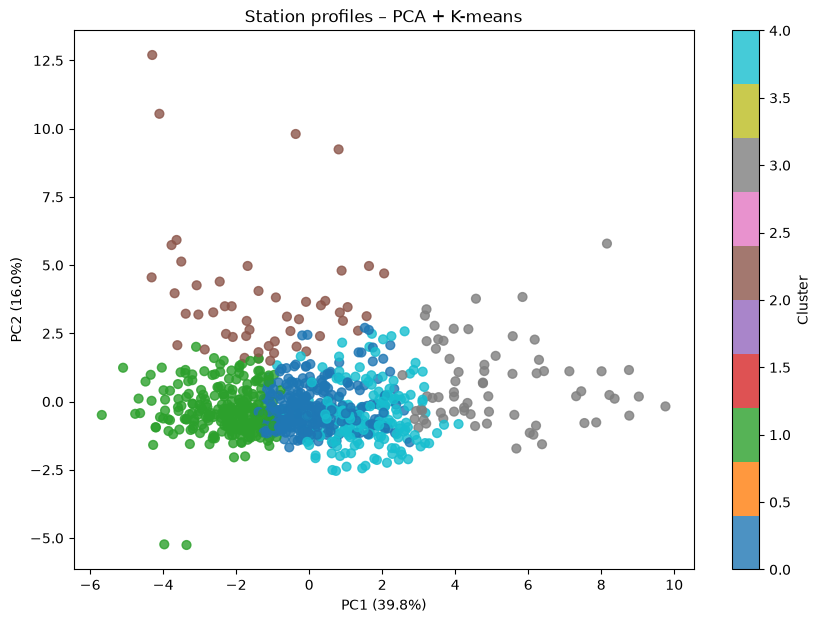

In [16]:
################3
#Color PCA plot by cluster
#################

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap="tab10",
    s=40,
    alpha=0.8
)

plt.xlabel(f"PC1 ({explained_variance[0]:.1%})")
plt.ylabel(f"PC2 ({explained_variance[1]:.1%})")
plt.title("Station profiles – PCA + K-means")

plt.colorbar(scatter, label="Cluster")

plt.show()

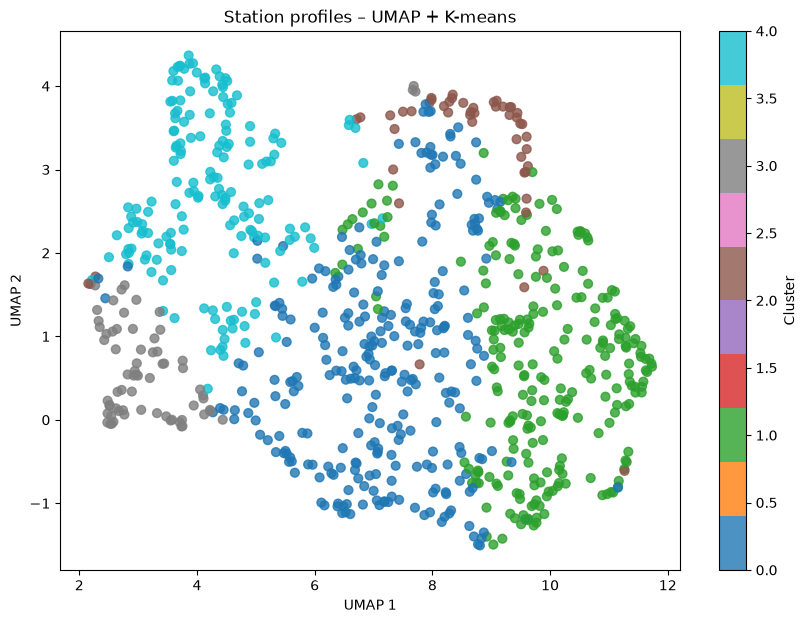

In [17]:
#and same for umap
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=labels,
    cmap="tab10",
    s=40,
    alpha=0.8
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Station profiles – UMAP + K-means")

plt.colorbar(scatter, label="Cluster")

plt.show()


In [18]:
# --------------------------------------------------------------------
# CLAUDE'S FIX -- this cell was missing entirely
# --------------------------------------------------------------------
# The cells below (outlier detection, cluster summary) reference a
# `cluster` column and a `distance_to_cluster_center` column on `stations`
# that are never created anywhere in this notebook -- running them as-is
# raises a ColumnNotFoundError / NameError for `stations_analysis`.
# The equivalent step already exists in "5. clustering.py"; it's just
# missing from this notebook. Adding it here: attach the k=5 K-means
# labels chosen above to the stations table, and compute each station's
# distance to its own cluster's centroid.

closest, distances = pairwise_distances_argmin_min(
    X_scaled,
    kmeans.cluster_centers_
)

stations_analysis = stations.with_columns([
    pl.Series("cluster", labels),
    pl.Series("distance_to_cluster_center", distances)
])


In [19]:
##############
#Find atypical or isolated stations
###############

#-------------
# distance from the cluster centroid
#-------------

# CLAUDE'S FIX: this referenced `stations`, which has no 'cluster' or
# 'distance_to_cluster_center' column -- swapped to `stations_analysis`
# (built in the cell just above) which has both.

cluster_thresholds = (
    stations_analysis
    .group_by("cluster")
    .agg(
        pl.col("distance_to_cluster_center")
        .quantile(0.99)
        .alias("outlier_threshold")
    )
)

outliers = (
    stations_analysis
    .join(cluster_thresholds, on="cluster")
    .filter(
        pl.col("distance_to_cluster_center")
        >= pl.col("outlier_threshold")
    )
    .sort("distance_to_cluster_center", descending=True)
)

print(
    outliers.select([
        "station",
        "cluster",
        "distance_to_cluster_center",
        "outlier_threshold"
    ])
)

# --------------------------------------------------------------------
# CLAUDE'S NOTE -- 14 rows flagged, but two of them share a fake
# station id and are actually the most interesting finding here
# --------------------------------------------------------------------
# Taking the top-1%-furthest-from-centroid *within each cluster*
# (rather than one global threshold) flags 14 rows out of 822 stations.
# Two of them are both "station 0" (distances 12.01 and 11.82, both the
# single most extreme point in cluster 1, well above its 6.02
# threshold). Checking "4.stations_df.csv" directly: there really are
# two distinct rows with station id "0" (n_arrivals=607/n_origins=354
# and n_arrivals=199/n_origins=152, both with n_departures=0 and every
# duration/time-of-day feature at 0). This isn't two genuinely identical
# stations -- it's a join bug upstream in
# "4. profile_station_data_analysis.py":
# `departures.join(arrivals, on="station", how="full")` doesn't
# coalesce the join key, so any station that only ever appears in
# `arrivals` (i.e. has 0 departures) gets a null `station` id from the
# `departures` side, and the following `.fill_null(0)` silently turns
# that null into 0 -- for *every* such station, collapsing them all
# into one fake "station 0". (These are almost certainly the same two
# real stations flagged as 10626 and 22168 in the origin-destination
# notebook -- same out_degree of 0, and the same weighted_in_degree of
# 607 / 199.) Since "station 0" isn't a real station, it shouldn't be
# reported as an atypical one -- and the same artifact resurfaces in
# the isolation-forest, activity-outlier and ratio-outlier cells below.
# Worth fixing the join upstream (`coalesce=True`, or filling the id
# from whichever side has it) before trusting any of these lists.

shape: (14, 4)
┌─────────┬─────────┬────────────────────────────┬───────────────────┐
│ station ┆ cluster ┆ distance_to_cluster_center ┆ outlier_threshold │
│ ---     ┆ ---     ┆ ---                        ┆ ---               │
│ i64     ┆ i32     ┆ f64                        ┆ f64               │
╞═════════╪═════════╪════════════════════════════╪═══════════════════╡
│ 1101    ┆ 2       ┆ 14.175483                  ┆ 14.175483         │
│ 0       ┆ 1       ┆ 12.00555                   ┆ 6.023219          │
│ 0       ┆ 1       ┆ 11.815095                  ┆ 6.023219          │
│ 1072    ┆ 3       ┆ 10.891885                  ┆ 7.504385          │
│ 2696    ┆ 3       ┆ 7.504385                   ┆ 7.504385          │
│ …       ┆ …       ┆ …                          ┆ …                 │
│ 1158    ┆ 4       ┆ 4.754318                   ┆ 3.89053           │
│ 200017  ┆ 0       ┆ 4.632058                   ┆ 4.601538          │
│ 2660    ┆ 0       ┆ 4.601538                   ┆ 4.601538   

In [20]:
print(
    stations_analysis.select([
        pl.col("distance_to_cluster_center").quantile(0.50).alias("median"),
        pl.col("distance_to_cluster_center").quantile(0.75).alias("q75"),
        pl.col("distance_to_cluster_center").quantile(0.90).alias("q90"),
        pl.col("distance_to_cluster_center").quantile(0.95).alias("q95"),
        pl.col("distance_to_cluster_center").quantile(0.99).alias("q99"),
    ])
)

#"The stations identified as atypical are those in the upper 1% of distances to their cluster centroid."

# --------------------------------------------------------------------
# CLAUDE'S NOTE
# --------------------------------------------------------------------
# Context for the thresholds used in the previous cell: the median
# station sits only 2.15 (standardised) units from its own centroid,
# and even the 95th percentile is 4.35 -- so the 6.02-7.50 per-cluster
# q99 thresholds used above are genuinely far out in the tail, not an
# arbitrary cutoff. The jump from q95 (4.35) to q99 (7.31) is also much
# bigger than from q90 (3.75) to q95 -- the distance distribution has a
# long tail, consistent with a handful of real outlier stations rather
# than a gradual spread.

shape: (1, 5)
┌──────────┬──────────┬──────────┬──────────┬──────────┐
│ median   ┆ q75      ┆ q90      ┆ q95      ┆ q99      │
│ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞══════════╪══════════╪══════════╪══════════╪══════════╡
│ 2.150585 ┆ 2.808118 ┆ 3.749678 ┆ 4.351235 ┆ 7.312548 │
└──────────┴──────────┴──────────┴──────────┴──────────┘


In [21]:
#---------------------
#Isolation forest
#---------------------
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

outlier_labels = iso.fit_predict(X_scaled)

stations_iforest = stations.with_columns(
    pl.Series("isolation_outlier", outlier_labels.tolist())
)

outliers_iforest = (
    stations_iforest
    .filter(pl.col("isolation_outlier") == -1)
)

print(
    outliers_iforest.select("station")
)

# --------------------------------------------------------------------
# CLAUDE'S NOTE -- "station 0" again, and a useful cross-check with
# the distance-based method above
# --------------------------------------------------------------------
# contamination=0.01 on 822 stations targets ~8 outliers; 9 came back,
# which is expected rounding. The fake "station 0" (see the note two
# cells up) shows up twice here too, exactly as it did with the
# distance-to-centroid method -- it's flagged as extreme by every
# method in this section because its features are all zero, which is
# genuinely unlike any real station. The other 7 stations (1072, 1075,
# 2635, 200009, 2696, 200233, 1101) partially overlap with the
# distance-based outliers above (1072, 2696, 1101 appear in both lists),
# which is a good sanity check -- two different outlier-detection
# methods agreeing on the same real stations is more convincing than
# either one alone.

shape: (9, 1)
┌─────────┐
│ station │
│ ---     │
│ i64     │
╞═════════╡
│ 1072    │
│ 1075    │
│ 0       │
│ 2635    │
│ 200009  │
│ 2696    │
│ 200233  │
│ 0       │
│ 1101    │
└─────────┘


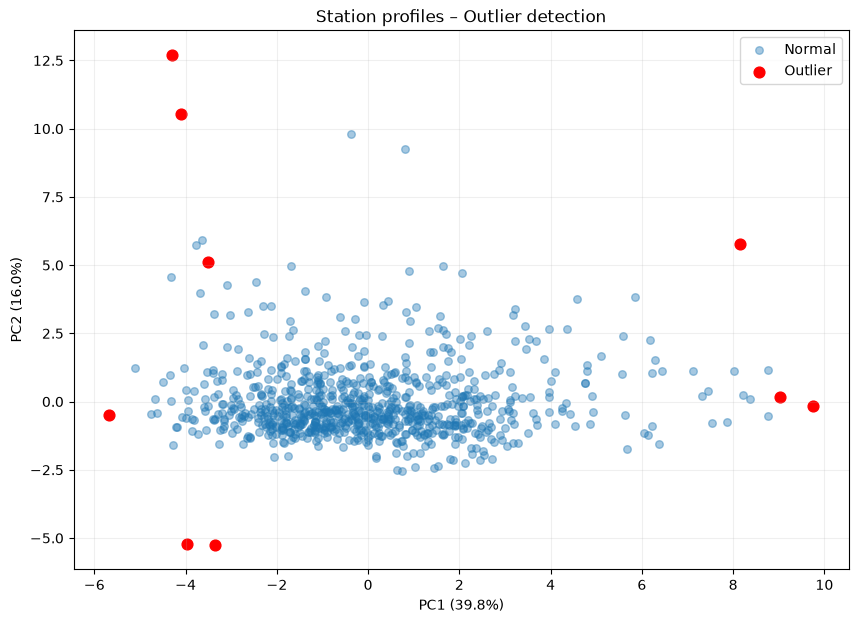

In [22]:
#---------------
#Outliers graph
#---------------

plt.figure(figsize=(10, 7))

normal = outlier_labels == 1
outlier = outlier_labels == -1

plt.scatter(
    X_pca[normal, 0],
    X_pca[normal, 1],
    alpha=0.4,
    s=30,
    label="Normal"
)

plt.scatter(
    X_pca[outlier, 0],
    X_pca[outlier, 1],
    color="red",
    s=60,
    label="Outlier"
)

plt.xlabel(f"PC1 ({explained_variance[0]:.1%})")
plt.ylabel(f"PC2 ({explained_variance[1]:.1%})")
plt.title("Station profiles – Outlier detection")
plt.legend()
plt.grid(alpha=0.2)

plt.show()


In [23]:
#--------------------------
#Very low or high activity
#--------------------------
#check distribution
print(stations.select([
    pl.col("n_departures").quantile(0.01).alias("p01"),
    pl.col("n_departures").quantile(0.05).alias("p05"),
    pl.col("n_departures").median().alias("median"),
    pl.col("n_departures").quantile(0.95).alias("p95"),
    pl.col("n_departures").quantile(0.99).alias("p99"),
]))

#Identify station in the top 1% of departures
q01_dep = stations["n_departures"].quantile(0.01)
q99_dep = stations["n_departures"].quantile(0.99)

activity_outliers_dep = stations.filter(
    (pl.col("n_departures") <= q01_dep) |
    (pl.col("n_departures") >= q99_dep)
)

#Identify station in the top 1% of arrivals
q01_arr = stations["n_arrivals"].quantile(0.01)
q99_arr = stations["n_arrivals"].quantile(0.99)

activity_outliers_arr = stations.filter(
    (pl.col("n_arrivals") <= q01_arr) |
    (pl.col("n_arrivals") >= q99_arr)
)

# Total activity = departures + arrivals
stations = stations.with_columns(
    (
        pl.col("n_departures") + pl.col("n_arrivals")
    ).alias("total_activity")
)

# 1st and 99th percentiles
q01_activity = stations["total_activity"].quantile(0.01)
q99_activity = stations["total_activity"].quantile(0.99)

# Identify unusually low or high activity stations
activity_outliers = stations.filter(
    (pl.col("total_activity") <= q01_activity) |
    (pl.col("total_activity") >= q99_activity)
)



print(
    activity_outliers.select([
        "station",
        "n_departures",
        "n_arrivals",
        "total_activity"
    ])
)

# --------------------------------------------------------------------
# CLAUDE'S NOTE -- 18 stations at both ends of the activity spectrum
# --------------------------------------------------------------------
# This flags 18 stations combining the bottom and top 1% of total
# activity (departures + arrivals). At the top: station 1072
# (104,443 trips/year) and 1075 (79,668) -- consistent with them
# showing up as hubs in every other method in this notebook and in the
# origin-destination notebook's weighted-degree rankings. At the
# bottom: real, very low-traffic stations like 2635 (64 trips/year
# total) sit alongside "station 0" again (607 and 199 -- see the notes
# above on why that id is a data artifact, not a real station). Also
# worth noting several of the low-activity real stations have ids
# ending in "444" (e.g. 200191444, 11274444) -- these look like the
# secondary station-id scheme flagged in the very first cell of this
# notebook (the ~2 billion outlier id), so it may be worth checking
# whether that id scheme systematically corresponds to a different
# type of dock (e-bike bays, seasonal/temporary stations, etc.) that
# would legitimately have low year-round activity for reasons other
# than being "atypical".

shape: (1, 5)
┌───────┬────────┬────────┬─────────┬─────────┐
│ p01   ┆ p05    ┆ median ┆ p95     ┆ p99     │
│ ---   ┆ ---    ┆ ---    ┆ ---     ┆ ---     │
│ f64   ┆ f64    ┆ f64    ┆ f64     ┆ f64     │
╞═══════╪════════╪════════╪═════════╪═════════╡
│ 841.0 ┆ 2950.0 ┆ 9550.0 ┆ 21933.0 ┆ 32640.0 │
└───────┴────────┴────────┴─────────┴─────────┘
shape: (18, 4)
┌───────────┬──────────────┬────────────┬────────────────┐
│ station   ┆ n_departures ┆ n_arrivals ┆ total_activity │
│ ---       ┆ ---          ┆ ---        ┆ ---            │
│ i64       ┆ i64          ┆ i64        ┆ i64            │
╞═══════════╪══════════════╪════════════╪════════════════╡
│ 1072      ┆ 53880        ┆ 50563      ┆ 104443         │
│ 1075      ┆ 42737        ┆ 36931      ┆ 79668          │
│ 0         ┆ 0            ┆ 607        ┆ 607            │
│ 2635      ┆ 37           ┆ 27         ┆ 64             │
│ 200083444 ┆ 488          ┆ 554        ┆ 1042           │
│ …         ┆ …            ┆ …          ┆ …  

In [24]:
#--------------------
#Extreme departures/arrivales ration
#--------------------

stations_ratio = stations.with_columns(
    (
        pl.col("n_departures") /
        (pl.col("n_departures") + pl.col("n_arrivals"))
    ).alias("departure_share")
)

print(
    stations_ratio
    .sort("departure_share")
    .select([
        "station",
        "n_departures",
        "n_arrivals",
        "departure_share"
    ])
    .head(10)
)

print(
    stations_ratio
    .sort("departure_share", descending=True)
    .select([
        "station",
        "n_departures",
        "n_arrivals",
        "departure_share"
    ])
    .head(10)
)

#close to 0.5 → balanced
#close to 1 → mostly departures
#close to 0 → mostly arrivals

# --------------------------------------------------------------------
# CLAUDE'S NOTE -- the two "0.0" rows at the top are the same data
# artifact, not real all-arrivals stations
# --------------------------------------------------------------------
# The most extreme departure_share values (0.0) are, once again, the
# two "station 0" rows (n_departures=0 by construction of the id bug
# noted above -- of course their ratio is exactly 0). Excluding those,
# the real most arrival-skewed station is 200226 at 0.375, and the most
# departure-skewed is 1101 at 0.726 -- much less extreme than the fake
# 0.0/1.0 values "station 0" would otherwise represent, and consistent
# with 1101 and 200017 also showing up as strongly one-directional in
# the origin-destination notebook's flow-imbalance ranking.

shape: (10, 4)
┌─────────┬──────────────┬────────────┬─────────────────┐
│ station ┆ n_departures ┆ n_arrivals ┆ departure_share │
│ ---     ┆ ---          ┆ ---        ┆ ---             │
│ i64     ┆ i64          ┆ i64        ┆ f64             │
╞═════════╪══════════════╪════════════╪═════════════════╡
│ 0       ┆ 0            ┆ 607        ┆ 0.0             │
│ 0       ┆ 0            ┆ 199        ┆ 0.0             │
│ 200226  ┆ 10824        ┆ 18015      ┆ 0.375325        │
│ 982     ┆ 19593        ┆ 30817      ┆ 0.388673        │
│ 2688    ┆ 6265         ┆ 9062       ┆ 0.408756        │
│ 200072  ┆ 10838        ┆ 15551      ┆ 0.410701        │
│ 1067    ┆ 28981        ┆ 40483      ┆ 0.417209        │
│ 1061    ┆ 4564         ┆ 6352       ┆ 0.418102        │
│ 3431    ┆ 5616         ┆ 7679       ┆ 0.422414        │
│ 200253  ┆ 7301         ┆ 9965       ┆ 0.422854        │
└─────────┴──────────────┴────────────┴─────────────────┘
shape: (10, 4)
┌─────────┬──────────────┬────────────┬───

In [25]:
#----------------
#atypical hour profile
#----------------
stations_pca = stations.with_columns([
    pl.Series("PC1", X_pca[:, 0].tolist()),
    pl.Series("PC2", X_pca[:, 1].tolist()),
    pl.Series("PC3", X_pca[:, 2].tolist())
])

# CLAUDE'S FIX: neither of these two tables was actually visible before --
# only the very last expression in a cell auto-displays in Jupyter, and
# there are trailing comment lines below (comments don't count), so the
# ascending-sort table below was silently computed and discarded, and
# only the descending one ever showed up in the output. Added print() to
# both so both ends of PC1 are actually shown.
print(
    stations_pca.sort("PC1").select([
        "station",
        "PC1",
        "PC2",
        "PC3"
    ]).head(10)
)
print(
    stations_pca.sort("PC1", descending=True).select([
        "station",
        "PC1",
        "PC2",
        "PC3"
    ]).head(10)
)


#Which stations have an unusual distribution of activity throughout the day?

#And you already have the tools to do this.

#Your PCA showed:

#PC1 ≈ morning vs evening behaviour
#PC2 ≈ night/early morning behaviour
#PC3 ≈ midday/weekend behaviour
#So a station with an extreme PCA score can potentially be considered temporally atypical.

# --------------------------------------------------------------------
# CLAUDE'S NOTE -- with the fix above, the low-PC1 end is now visible,
# and it doesn't match the "PC1 = morning vs evening" label above
# --------------------------------------------------------------------
# Recall from the PCA-loadings note earlier in this notebook: with the
# 'station' ID bug fixed, PC1's top loadings are all usage-*volume*
# variables (n_arrivals, n_departures, avg_daily_*, n_origins), not a
# morning/evening split -- so "atypical PC1" here means "atypically
# busy or atypically quiet", not "atypical time-of-day profile". The
# high-PC1 stations printed above (1072, 2696, 2587, 960, ...) are
# exactly the same handful of hub stations flagged everywhere else in
# this section. The low-PC1 stations (2635, 11274444, 1219444,
# 200191444, 200254, ...) are simply the quietest stations -- several
# again with the "444"-suffixed ids noted in the activity-outlier cell
# above. For a genuinely *temporal* atypicality (unusual hour-of-day
# shape rather than unusual volume), PC2 and PC3 -- which do carry the
# duration / rush-hour / weekend signal -- are the more relevant axes
# to sort by than PC1.

shape: (10, 4)
┌───────────┬───────────┬───────────┬───────────┐
│ station   ┆ PC1       ┆ PC2       ┆ PC3       │
│ ---       ┆ ---       ┆ ---       ┆ ---       │
│ i64       ┆ f64       ┆ f64       ┆ f64       │
╞═══════════╪═══════════╪═══════════╪═══════════╡
│ 2635      ┆ -5.68122  ┆ -0.490199 ┆ 0.171753  │
│ 11274444  ┆ -5.098073 ┆ 1.239947  ┆ -0.204356 │
│ 1219444   ┆ -4.766159 ┆ -0.448517 ┆ -1.054641 │
│ 200191444 ┆ -4.672575 ┆ 0.109494  ┆ 1.054403  │
│ 200254    ┆ -4.631573 ┆ -0.422509 ┆ -0.14449  │
│ 300084    ┆ -4.483401 ┆ 0.734288  ┆ 0.986553  │
│ 200224    ┆ -4.342186 ┆ 0.981766  ┆ 0.488762  │
│ 1111      ┆ -4.317667 ┆ 0.028877  ┆ -0.102622 │
│ 200092    ┆ -4.315875 ┆ 4.551307  ┆ 1.530084  │
│ 200009    ┆ -4.299624 ┆ 12.70011  ┆ 3.371314  │
└───────────┴───────────┴───────────┴───────────┘
shape: (10, 4)
┌─────────┬──────────┬───────────┬───────────┐
│ station ┆ PC1      ┆ PC2       ┆ PC3       │
│ ---     ┆ ---      ┆ ---       ┆ ---       │
│ i64     ┆ f64      ┆ f64   

In [26]:
#################33
#Make clusters interpretables
##################

cluster_summary = (
    stations_analysis
    .group_by("cluster")
    .agg([
        pl.col(c).mean().alias(c)
        for c in feature_columns
    ])
)

print(cluster_summary)

# --------------------------------------------------------------------
# CLAUDE'S NOTE -- ties the k=5 clusters back to the PCA/feature
# interpretation earlier in this notebook
# --------------------------------------------------------------------
# Cluster 3 stands out with by far the highest volume (mean
# n_departures=25,472, n_arrivals=26,930) and the highest
# evening_rush_ratio (0.307) but the lowest weekend_ratio (0.221) --
# these are the busy, commute-driven hub stations (matching PC1="usage
# volume" and the hub stations flagged throughout the atypical-stations
# section above, e.g. 1072, 2696, 2587). Cluster 4 has the highest
# evening_rush_ratio of all (0.375) combined with the lowest
# morning_rush_ratio (0.100) and lowest weekend_ratio (0.182) -- a
# clearly evening/commute-skewed profile. Cluster 2 has the highest
# weekend_ratio (0.292) and a comparatively low evening_rush_ratio
# (0.236) -- more leisure/weekend-driven, lower-volume stations. This
# is a useful sanity check that the k=5 clusters chosen earlier do
# separate along the same dimensions PC1-PC3 already pointed to
# (volume, evening rush, weekend), rather than an unrelated split.

shape: (5, 15)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ cluster ┆ n_departur ┆ avg_daily ┆ n_arrival ┆ … ┆ weekend_r ┆ morning_r ┆ evening_r ┆ night_rat │
│ ---     ┆ es         ┆ _departur ┆ s         ┆   ┆ atio      ┆ ush_ratio ┆ ush_ratio ┆ io        │
│ i32     ┆ ---        ┆ es        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ f64        ┆ ---       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│         ┆            ┆ f64       ┆           ┆   ┆           ┆           ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 1       ┆ 5618.22134 ┆ 16.702631 ┆ 5341.5138 ┆ … ┆ 0.251772  ┆ 0.284407  ┆ 0.191561  ┆ 0.026242  │
│         ┆ 4          ┆           ┆ 34        ┆   ┆           ┆           ┆           ┆           │
│ 3       ┆ 25471.7058 ┆ 70.220376 ┆ 26930.147 ┆ … ┆ 0.221054  ┆ 0.158021  ┆